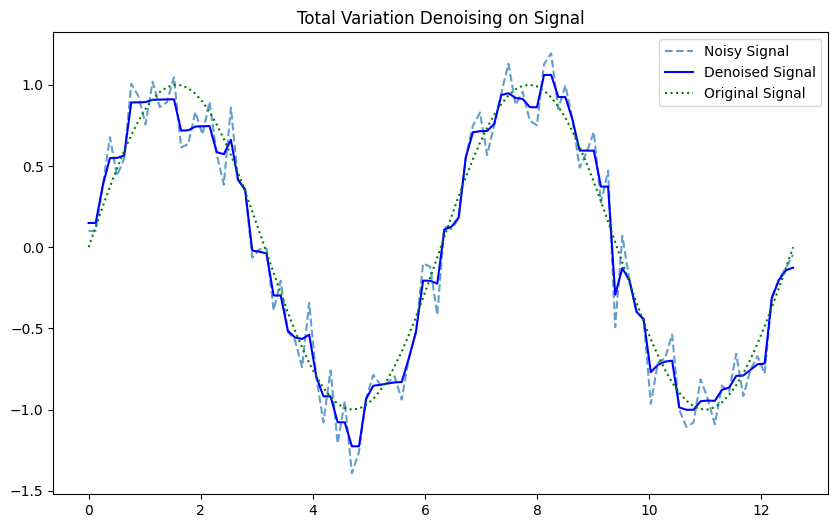

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import denoise_tv_chambolle

# Generate a noisy signal
np.random.seed(42)
x = np.linspace(0, 4 * np.pi, 100)
signal = np.sin(x)
noisy_signal = signal + np.random.normal(0, 0.2, signal.shape)

# Apply TVD
denoised_signal = denoise_tv_chambolle(noisy_signal, weight=0.1)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(x, noisy_signal, label="Noisy Signal", linestyle="--", alpha=0.7)
plt.plot(x, denoised_signal, label="Denoised Signal", color="blue")
plt.plot(x, signal, label="Original Signal", color="green", linestyle="dotted")
plt.legend()
plt.title("Total Variation Denoising on Signal")
plt.show()


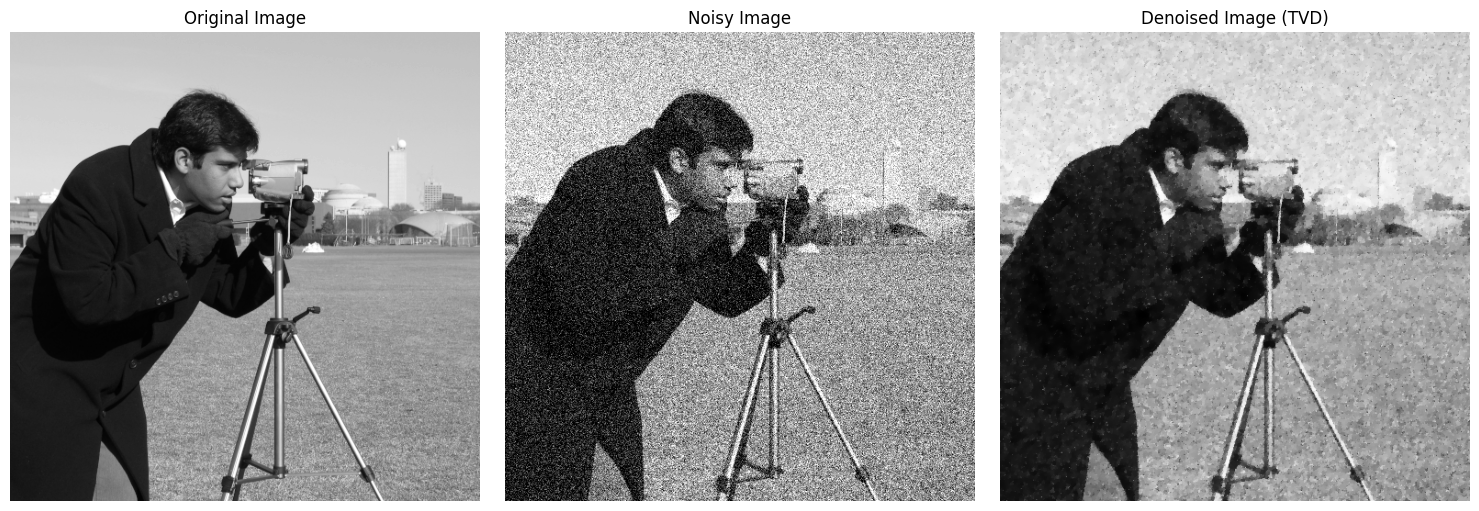

In [ ]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import random_noise
from skimage.restoration import denoise_tv_chambolle

# Load a sample image from sklearn.datasets
image = data.camera()

# Add noise to the image
noisy_image = random_noise(image, mode='gaussian', var=0.03)  # Gaussian noise with variance 0.02

# Apply Total Variation Denoising (TVD)
lambda_param = 0.1  # Regularization parameter
denoised_image = denoise_tv_chambolle(noisy_image, weight=lambda_param)

# Plotting the original, noisy, and denoised images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(noisy_image, cmap='gray')
ax[1].set_title("Noisy Image")
ax[1].axis('off')

ax[2].imshow(denoised_image, cmap='gray')
ax[2].set_title("Denoised Image (TVD)")
ax[2].axis('off')

plt.tight_layout()
plt.show()


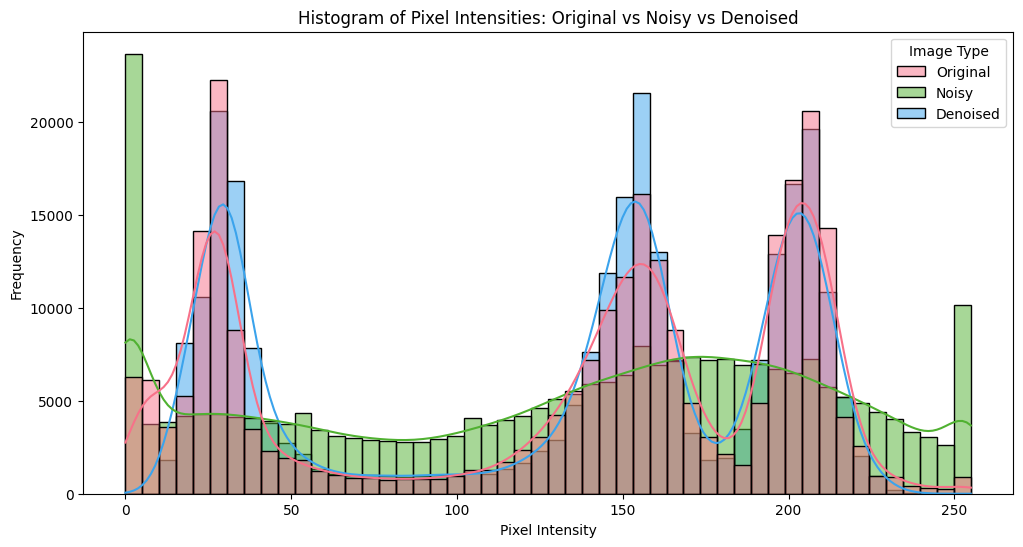

In [ ]:
import seaborn as sns

# Flatten images for histogram comparison
original_flat = image.ravel()
noisy_flat = (noisy_image * 255).astype(np.uint8).ravel()  # Scale noisy image to match original's intensity
denoised_flat = (denoised_image * 255).astype(np.uint8).ravel()

# Create a DataFrame for better visualization with Seaborn
import pandas as pd

data_hist = pd.DataFrame({
    'Pixel Intensity': np.concatenate([original_flat, noisy_flat, denoised_flat]),
    'Image Type': ['Original'] * len(original_flat) +
                  ['Noisy'] * len(noisy_flat) +
                  ['Denoised'] * len(denoised_flat)
})

# Plot the histograms
plt.figure(figsize=(12, 6))
sns.histplot(data=data_hist, x='Pixel Intensity', hue='Image Type', kde=True, bins=50, palette='husl')
plt.title('Histogram of Pixel Intensities: Original vs Noisy vs Denoised')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()
